# Supplementary Fig. 1 — UKCTOCS cell-type deconvolution

Blood cell-type proportions were estimated from whole-genome bisulphite sequencing of 94 UKCTOCS
samples using the **EpiDISH** package. The **88** samples meeting the minimum coverage criterion
(≥ 286 of 333 CpGs; 44 pre-AML and 44 controls) are shown.

- **a** — estimated proportion of each blood cell type per sample, EpiDISH **CBS** method (points;
  case = pink, control = light blue; bars = per-cell-type medians for cases (red) and controls (blue)).
- **b** — the same, EpiDISH **RPC** method.
- **c** — for each cell type, estimated proportion vs the sample's mean methylation (Pearson *r*, *p*),
  showing that the case outliers are hypermethylated samples (a disease signal) rather than a true
  change in cell proportions. Black line = mean methylation across samples.

## Data availability

The deconvolution **result files** are derived from individual-level UKCTOCS whole-genome bisulphite data; the raw methylation data and the upstream pipeline inputs are **not distributed**. Samples are labelled by sequencing library (e.g. `SLX-19316.U001`), not by participant.

| file | used for | location |
|---|---|---|
| `epidish_results_per_sample_96.csv` | cell-type proportions, CBS method (94 samples) — panels a, c | Data_files/EpiDISH |
| `epidish_results_per_sample_96_RPC.csv` | cell-type proportions, RPC method — panel b | Data_files/EpiDISH |
| `UKCTOCS_deconvolution_CpG_coverage_and_mean_methylation.csv` | CpGs covered and mean methylation per sample — coverage filtering & panel c | Data_files/EpiDISH |

The per-sample coverage filter (originally read from per-sample JSON files) is reconstructed from
the CpG counts in the summary table; this reproduces the published 88-of-94 sample selection
exactly. 

## 1. Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
%matplotlib inline

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Helvetica'

## 2. Case / control sample lists

In [13]:
case_samples=['SLX-19316.U001.','SLX-19316.U003.','SLX-19316.U006.','SLX-19316.U010.','SLX-19316.U011.','SLX-19316.U012.','SLX-19317.U013.','SLX-19317.U015.','SLX-19317.U017.',
        'SLX-19317.U019.','SLX-19317.U021.','SLX-19317.U023.','SLX-20578.U023.','SLX-20579.U005.',
         'SLX-20579.U007.','SLX-20579.U009.','SLX-20579.U011.','SLX-20580.U013.',
         'SLX-20580.U015.','SLX-20580.U017.','SLX-20580.U019.','SLX-20580.U021.','SLX-20580.U022.','SLX-19318.U003.','SLX-19318.U005.','SLX-19318.U007.',
             'SLX-19318.U009.','SLX-19318.U022.','SLX-19319.U001.','SLX-19319.U011.','SLX-19319.U014.','SLX-19319.U016.','SLX-19319.U018.','SLX-19319.U020.',
              'SLX-20577.U001.','SLX-20577.U003.','SLX-20577.U005.','SLX-20577.U007.','SLX-20577.U009.','SLX-20577.U011.','SLX-20578.U013.','SLX-20578.U015.',
              'SLX-20578.U017.','SLX-20578.U019.','SLX-20578.U021.','SLX-20579.U001.','SLX-20579.U003.']

control_samples=['SLX-19316.U002.','SLX-19316.U004.','SLX-19316.U005.','SLX-19316.U007.','SLX-19316.U008.','SLX-19316.U009.','SLX-19317.U014.','SLX-19317.U016.','SLX-19317.U018.',
                'SLX-19317.U020.','SLX-19317.U022.','SLX-19317.U024.','SLX-20578.U024.','SLX-20579.U006.','SLX-20579.U008.','SLX-20579.U010.','SLX-20579.U012.','SLX-20580.U014.','SLX-20580.U016.',
                'SLX-20580.U018.','SLX-20580.U020.','SLX-20580.U023.','SLX-20580.U024.','SLX-19318.U004.','SLX-19318.U006.','SLX-19318.U008.','SLX-19318.U010.',
                'SLX-19318.U023.','SLX-19319.U002.','SLX-19319.U013.','SLX-19319.U015.','SLX-19319.U017.','SLX-19319.U019.','SLX-19319.U021.',
                'SLX-20577.U002.','SLX-20577.U004.','SLX-20577.U006.','SLX-20577.U008.','SLX-20577.U010.','SLX-20577.U012.',
                'SLX-20578.U014.','SLX-20578.U016.','SLX-20578.U018.','SLX-20578.U020.','SLX-20578.U022.','SLX-20579.U002.','SLX-20579.U004.']


case_samples_corrected=[x.replace('-', '.') for x in case_samples]
control_samples_corrected=[x.replace('-', '.') for x in control_samples]

## 3. Coverage filtering

Per-sample coverage = the number of reference CpGs covered in that sample. Samples more than 2 s.d.
below the mean coverage are dropped (88 of 94 retained), reproducing the published selection.

In [14]:
#CpG coverage and mean methylation per sample, precomputed from the EpiDISH deconvolution CpG matrix
#(the full 327 CpG x 94 sample methylation matrix is not distributed: the figure only needs these two summaries)
meths_summary_df = pd.read_csv('Data_files/EpiDISH/UKCTOCS_deconvolution_CpG_coverage_and_mean_methylation.csv', index_col=0)

# CpGs covered per sample (replaces the original per-sample JSON coverage read)
coverage_dict = meths_summary_df['cpgs_covered'].to_dict()
all_coverages = list(coverage_dict.values())
thresh = np.mean(all_coverages) - (np.std(all_coverages) * 2)

# sample names to drop, in the two naming conventions used downstream
samples_below_cov = [k.replace('-', '.') for k, v in coverage_dict.items() if v < thresh]
samples_below_cov_same_name = [k for k, v in coverage_dict.items() if v < thresh]
print(f'{len(all_coverages) - len(samples_below_cov)} of {len(all_coverages)} samples retained')

88 of 94 samples retained


## 4. Panel a — cell-type proportions (CBS method)

In [15]:
deconvolution_df = pd.read_csv('Data_files/EpiDISH/epidish_results_per_sample_96.csv', index_col=0)  # CBS method

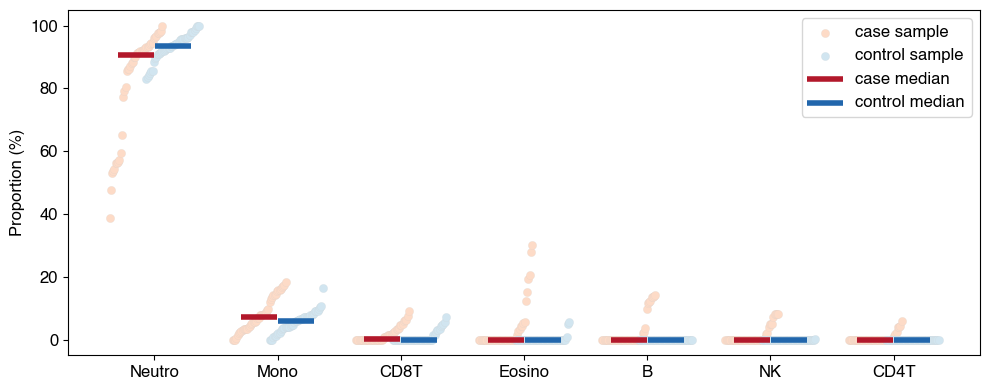

In [16]:
thresh=np.mean(all_coverages)-(np.std(all_coverages)*2)
samples_below_cov=[]
for k,v in coverage_dict.items():
    if v<thresh:
        samples_below_cov.append((k.replace('-','.')))

filtered_deconvolution_df=deconvolution_df.drop(columns=samples_below_cov)

df_scaled = filtered_deconvolution_df * 100

# Step 1: Reset index to make `cell_type` a column
deconvolution_df_w_row_col = df_scaled.reset_index().rename(columns={'index': 'cell_type'})
# Step 2: Melt the DataFrame to go from wide to long format
deconvolution_df_w_row_col_long = deconvolution_df_w_row_col.melt(id_vars=['cell_type'], var_name='sample', value_name='value')

# Step 3: Add a "group" column based on the sample lists
deconvolution_df_w_row_col_long_w_group=deconvolution_df_w_row_col_long.copy()
deconvolution_df_w_row_col_long_w_group['case_control_status'] = deconvolution_df_w_row_col_long['sample'].apply(
    lambda x: 'case' if x in case_samples_corrected else 'control'
)

df = deconvolution_df_w_row_col_long_w_group.copy()

# Calculate the median for each cell_type and group
median_df = df.groupby(['cell_type', 'case_control_status'])['value'].median().reset_index()

# Compute the highest median for each cell_type
median_max = median_df.groupby('cell_type')['value'].max()

# Compute the highest individual value for each cell_type
max_individual_value = df.groupby('cell_type')['value'].max()

# Sort by median (descending), then by highest individual value (descending)
sorted_cell_types = sorted(
    median_max.index, 
    key=lambda x: (-median_max[x], -max_individual_value[x])
)

# Map each cell_type to a base x position based on the sorted order
base_x_positions = {cell_type: i for i, cell_type in enumerate(sorted_cell_types)}

# Add x_position to median_df
group_offset = {'case': -0.15, 'control': 0.15}
median_df['x_position'] = median_df.apply(
    lambda row: (
        base_x_positions[row['cell_type']] + 
        group_offset[row['case_control_status']]
    ),
    axis=1
)

# Merge the median back into the original DataFrame
df = df.merge(median_df, on=['cell_type', 'case_control_status'], suffixes=('', '_median'))

# Assign ranks within each cell_type and group
df['rank'] = df.groupby(['cell_type', 'case_control_status'])['value'].rank(method='first').astype(int)
df = df.sort_values(['cell_type', 'case_control_status', 'value']).reset_index(drop=True)

# Adjust x positions to reflect equal distribution around the median
df['x_position'] = df.apply(
    lambda row: (
        base_x_positions[row['cell_type']] + 
        group_offset[row['case_control_status']] + 
        ((row['rank'] - (len(df[(df['cell_type'] == row['cell_type']) & (df['case_control_status'] == row['case_control_status'])]) + 1) / 2) * 0.01)
    ),
    axis=1
)

matplotlib.rcParams['pdf.fonttype']=42
matplotlib.rcParams['font.family']='Helvetica'

# Initialize the plot
plt.figure(figsize=(10, 4))

# Scatter plot with custom x positions
# for group, color in zip(['case', 'control'], ['#b2182b', '#2166ac']):
for group, color in zip(['case', 'control'], ['#fddbc7', '#d1e5f0']):
    subset = df[df['case_control_status'] == group]
    plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=1, color=color,edgecolors=(0.8, 0.8, 0.8, 0.1), linewidths=0.1)
    # plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=1, color=color,edgecolors=(0.7, 0.7, 0.7, 0.1), linewidths=0.1)
    # plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=0.5, color=color)

# # Overlay median values
# median_df['x_position'] = median_df.apply(
#     lambda row: base_x_positions[row['cell_type']] + group_offset[row['case_control_status']],
#     axis=1
# )
# plt.scatter(median_df['x_position'], median_df['value'], label='Median', color='black', s=100, marker='o')

# Define colors for medians
median_colors = {'case': '#b2182b', 'control': '#2166ac'}
# median_colors = {'case': '#67000d', 'control': '#08306b'}


# Scatter plot for median points with group-specific colors
for group in median_df['case_control_status'].unique():
    subset = median_df[median_df['case_control_status'] == group]
    plt.scatter(
        subset['x_position'], subset['value'], 
        color=median_colors[group], 
        label=f'{group} median', 
        s=700, marker='_', linewidths=4 
    )

# Improve aesthetics
plt.xticks(
    list(base_x_positions.values()),
    list(base_x_positions.keys()),fontsize=12
)
# plt.xlabel('Cell Type')
plt.ylabel('Proportion (%)',fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Ordered Data Points with Median Values')
plt.legend(fontsize=12)
# plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show plot
plt.tight_layout()
# plt.show()
plt.show()

In [17]:
df_scaled_cbs = df_scaled.copy()   # keep CBS proportions for panel c (panel b overwrites df_scaled)

## 5. Panel b — cell-type proportions (RPC method)

*Requires `Adriana EpiDISH/epidish_results_per_sample_96_RPC.csv` (the RPC-method counterpart of the
CBS file used in panel a). With that file present this cell reproduces panel b; the plotting code is
identical to panel a.*

In [18]:
deconvolution_df_RPC = pd.read_csv('Data_files/EpiDISH/epidish_results_per_sample_96_RPC.csv', index_col=0)  # RPC method

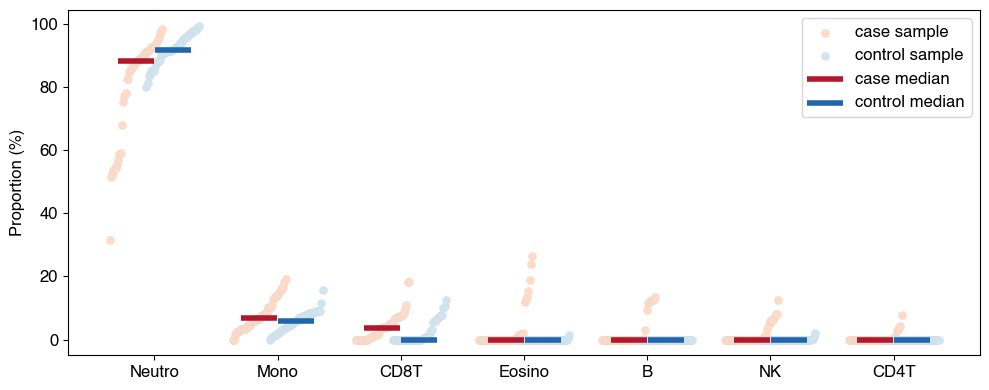

In [19]:
thresh=np.mean(all_coverages)-(np.std(all_coverages)*2)
samples_below_cov=[]
for k,v in coverage_dict.items():
    if v<thresh:
        samples_below_cov.append((k.replace('-','.')))

filtered_deconvolution_df=deconvolution_df_RPC.drop(columns=samples_below_cov)

df_scaled = filtered_deconvolution_df * 100

# Step 1: Reset index to make `cell_type` a column
deconvolution_df_w_row_col = df_scaled.reset_index().rename(columns={'index': 'cell_type'})
# Step 2: Melt the DataFrame to go from wide to long format
deconvolution_df_w_row_col_long = deconvolution_df_w_row_col.melt(id_vars=['cell_type'], var_name='sample', value_name='value')

# Step 3: Add a "group" column based on the sample lists
deconvolution_df_w_row_col_long_w_group=deconvolution_df_w_row_col_long.copy()
deconvolution_df_w_row_col_long_w_group['case_control_status'] = deconvolution_df_w_row_col_long['sample'].apply(
    lambda x: 'case' if x in case_samples_corrected else 'control'
)

df = deconvolution_df_w_row_col_long_w_group.copy()

# Calculate the median for each cell_type and group
median_df = df.groupby(['cell_type', 'case_control_status'])['value'].median().reset_index()

# Compute the highest median for each cell_type
median_max = median_df.groupby('cell_type')['value'].max()

# Compute the highest individual value for each cell_type
max_individual_value = df.groupby('cell_type')['value'].max()

# Sort by median (descending), then by highest individual value (descending)
sorted_cell_types = sorted(
    median_max.index, 
    key=lambda x: (-median_max[x], -max_individual_value[x])
)

# Map each cell_type to a base x position based on the sorted order
base_x_positions = {cell_type: i for i, cell_type in enumerate(sorted_cell_types)}

# Add x_position to median_df
group_offset = {'case': -0.15, 'control': 0.15}
median_df['x_position'] = median_df.apply(
    lambda row: (
        base_x_positions[row['cell_type']] + 
        group_offset[row['case_control_status']]
    ),
    axis=1
)

# Merge the median back into the original DataFrame
df = df.merge(median_df, on=['cell_type', 'case_control_status'], suffixes=('', '_median'))

# Assign ranks within each cell_type and group
df['rank'] = df.groupby(['cell_type', 'case_control_status'])['value'].rank(method='first').astype(int)
df = df.sort_values(['cell_type', 'case_control_status', 'value']).reset_index(drop=True)

# Adjust x positions to reflect equal distribution around the median
df['x_position'] = df.apply(
    lambda row: (
        base_x_positions[row['cell_type']] + 
        group_offset[row['case_control_status']] + 
        ((row['rank'] - (len(df[(df['cell_type'] == row['cell_type']) & (df['case_control_status'] == row['case_control_status'])]) + 1) / 2) * 0.01)
    ),
    axis=1
)

matplotlib.rcParams['pdf.fonttype']=42
matplotlib.rcParams['font.family']='Helvetica'

# Initialize the plot
plt.figure(figsize=(10, 4))

# Scatter plot with custom x positions
# for group, color in zip(['case', 'control'], ['#b2182b', '#2166ac']):
for group, color in zip(['case', 'control'], ['#fddbc7', '#d1e5f0']):
    subset = df[df['case_control_status'] == group]
    plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=1, color=color,edgecolors=(0.8, 0.8, 0.8, 0.1), linewidths=0.1)
    # plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=1, color=color,edgecolors=(0.7, 0.7, 0.7, 0.1), linewidths=0.1)
    # plt.scatter(subset['x_position'], subset['value'], label=f'{group} sample',alpha=0.5, color=color)

# # Overlay median values
# median_df['x_position'] = median_df.apply(
#     lambda row: base_x_positions[row['cell_type']] + group_offset[row['case_control_status']],
#     axis=1
# )
# plt.scatter(median_df['x_position'], median_df['value'], label='Median', color='black', s=100, marker='o')

# Define colors for medians
median_colors = {'case': '#b2182b', 'control': '#2166ac'}
# median_colors = {'case': '#67000d', 'control': '#08306b'}


# Scatter plot for median points with group-specific colors
for group in median_df['case_control_status'].unique():
    subset = median_df[median_df['case_control_status'] == group]
    plt.scatter(
        subset['x_position'], subset['value'], 
        color=median_colors[group], 
        label=f'{group} median', 
        s=700, marker='_', linewidths=4 
    )

# Improve aesthetics
plt.xticks(
    list(base_x_positions.values()),
    list(base_x_positions.keys()),fontsize=12
)
# plt.xlabel('Cell Type')
plt.ylabel('Proportion (%)',fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Ordered Data Points with Median Values')
plt.legend(fontsize=12)
# plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show plot
plt.tight_layout()
# plt.show()
plt.show()

## 6. Panel c — proportion vs mean methylation per cell type

Laid out as in the paper: one row of seven, ordered by decreasing abundance.

In [22]:
# mean methylation per (retained) sample, aligned to the proportion columns
meth_averages = meths_summary_df['mean_methylation'].drop(index=samples_below_cov_same_name)

# cell-type proportions (CBS), same 88 samples, keyed by cell type
prop_by_type = {ct: df_scaled_cbs.loc[ct].values for ct in df_scaled_cbs.index}

# published panel-c order (decreasing abundance) and display names
panel_c_order = ['Neutro', 'Mono', 'Eosino', 'NK', 'CD4T', 'CD8T', 'B']
display_names = {'Neutro': 'Neutrophils', 'Mono': 'Monocytes', 'Eosino': 'Eosinophils',
                 'NK': 'NK cells', 'CD4T': 'CD4 T-cells', 'CD8T': 'CD8 T-cells', 'B': 'B cells'}

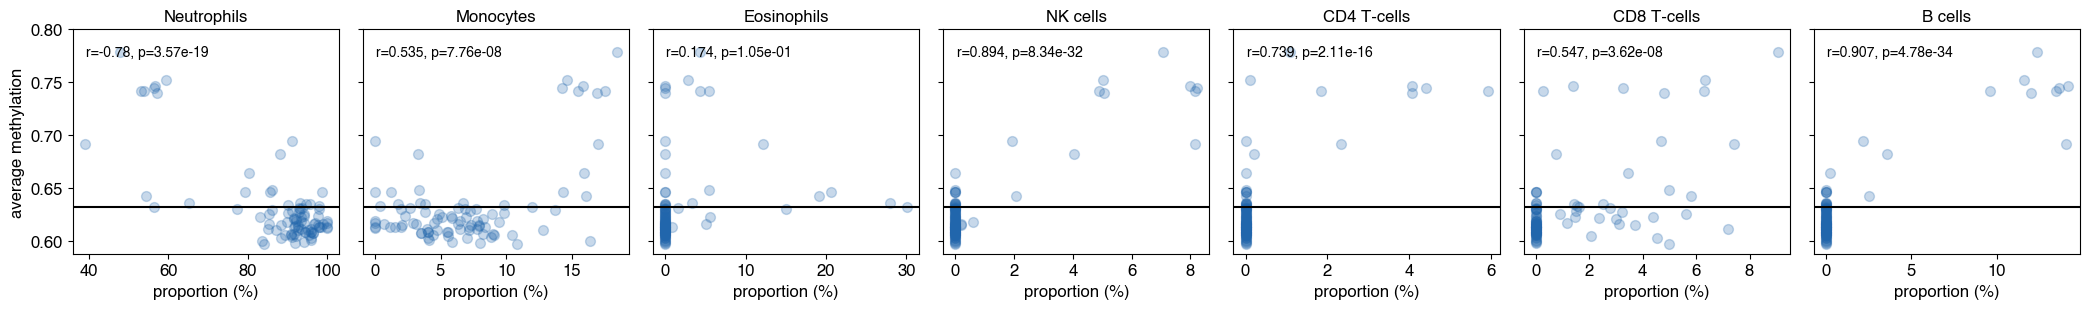

In [23]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Helvetica'
textsize = 12

f, ax = plt.subplots(1, 7, figsize=(21, 3.2), sharey=True)
plt.subplots_adjust(wspace=0.1)

for j, ct in enumerate(panel_c_order):
    prop = prop_by_type[ct]
    ax[j].scatter(prop, meth_averages, alpha=0.25, c='#2166ac', s=50)
    ax[j].axhline(y=np.mean(meth_averages), color='k')
    ax[j].set_title(display_names[ct], size=textsize)
    ax[j].set_xlabel('proportion (%)', size=textsize)
    ax[j].tick_params(labelsize=textsize)
    ax[j].set_yticks([0.6, 0.65, 0.7, 0.75, 0.8])
    r, p_value = pearsonr(prop, meth_averages)
    ax[j].text(0.05, 0.93, f'r={round(r, 3)}, p={"{:.2e}".format(p_value)}',
               transform=ax[j].transAxes, size=10, va='top')

ax[0].set_ylabel('average methylation', size=textsize)
plt.tight_layout()
plt.show()